<a href="https://colab.research.google.com/github/asmaa-2003/LSTM-Anomaly--detection/blob/main/SETRAM_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚃 SETRAM — Model Comparison
## 4 Models × 3 Datasets (MetroPT-1, MetroPT-2, MetroPT-3)

| Section | Content |
|---|---|
| 1 | Imports & Constants |
| 2 | Shared Data Pipeline (labels + features) |
| 3 | Model A — Random Forest |
| 4 | Model B — XGBoost |
| 5 | Model C — LSTM Classifier |
| 6 | Model D — LSTM Autoencoder |
| 7 | Cross-Dataset Comparison Table |
| 8 | Save All Models |

## 1. Imports & Constants

In [ ]:
import os, warnings, json
warnings.filterwarnings('ignore')
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from scipy import stats

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, precision_score,
                              recall_score, mean_absolute_error, r2_score)
import xgboost as xgb

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout,
                                      RepeatVector, TimeDistributed)
from tensorflow.keras.callbacks import EarlyStopping

# ── Directories ───────────────────────────────────────────
os.makedirs('model', exist_ok=True)
os.makedirs('output', exist_ok=True)

# ── Plot style ────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.facecolor': '#1a1a2e',
    'figure.facecolor': '#16213e',
    'axes.edgecolor': '#444',
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'grid.color': '#333',
    'grid.alpha': 0.4,
})

# ── Constants ─────────────────────────────────────────────
DATASETS = {
    'MetroPT1': 'MetroPT1.csv',
    'MetroPT2': 'MetroPT2.csv',
    'MetroPT3': 'MetroPT3.csv',
}

# Documented failures per dataset (from official maintenance reports)
FAILURES = {
    'MetroPT1': [
        ('2022-02-26', '2022-03-01', 'Air Leak — Clients'),
        ('2022-04-05', '2022-04-06', 'Air Leak — Dryer'),
        ('2022-06-02', '2022-06-03', 'Oil Leak — Compressor'),
    ],
    'MetroPT2': [
        ('2022-02-26', '2022-03-01', 'Air Leak — Clients'),
        ('2022-04-05', '2022-04-06', 'Air Leak — Dryer'),
        ('2022-06-02', '2022-06-03', 'Oil Leak — Compressor'),
    ],
    'MetroPT3': [
        ('2020-04-18', '2020-04-19', 'Air Leak — Clients'),
        ('2020-05-29', '2020-05-30', 'Air Leak — Dryer'),
        ('2020-06-05', '2020-06-07', 'Air Leak — Clients'),
        ('2020-07-15', '2020-07-16', 'Oil Leak — Compressor'),
    ],
}

SENSOR_COLS   = ['TP2','TP3','H1','DV_pressure','Reservoirs',
                 'Oil_temperature','Motor_current','Flowmeter','Caudal_impulse']
WARNING_HOURS = 24
WINDOW_HOURS  = 6
AVG_SPEED_KMH = 20.0
RANDOM_STATE  = 42
TIMESTEPS     = 10   # for LSTM

print('✓ All libraries loaded')
print(f'✓ TensorFlow: {tf.__version__} | XGBoost: {xgb.__version__}')

✓ All libraries loaded
✓ TensorFlow: 2.20.0 | XGBoost: 3.1.2


## 2. Shared Data Pipeline

In [ ]:
def load_and_clean(path: str) -> pd.DataFrame:
    """Load, deduplicate, sort, fill missing values."""
    df = pd.read_csv(path, parse_dates=['timestamp'], low_memory=False)
    df = df.drop_duplicates('timestamp').sort_values('timestamp').reset_index(drop=True)
    df = df.ffill().bfill()
    df['hour']      = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek
    df['is_peak']   = df['hour'].isin([7,8,9,17,18,19]).astype(int)
    return df


def add_labels(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """Add label (0/1/2), hours_to_failure, failure_type columns."""
    df = df.copy()
    df['label']            = 0
    df['failure_type']     = 'Normal'
    df['hours_to_failure'] = np.nan
    for s, e, ftype in FAILURES.get(dataset_name, []):
        t0 = pd.Timestamp(s)
        t1 = pd.Timestamp(e)
        tw = t0 - pd.Timedelta(hours=WARNING_HOURS)
        mw = (df['timestamp'] >= tw) & (df['timestamp'] < t0)
        mf = (df['timestamp'] >= t0) & (df['timestamp'] <= t1)
        df.loc[mw, 'label']            = 1
        df.loc[mw, 'failure_type']     = ftype
        df.loc[mw, 'hours_to_failure'] = (
            t0 - df.loc[mw, 'timestamp']).dt.total_seconds() / 3600
        df.loc[mf, 'label']            = 2
        df.loc[mf, 'failure_type']     = ftype
        df.loc[mf, 'hours_to_failure'] = 0.0
    return df


def linear_trend(s):
    if len(s) < 2: return 0.0
    try:
        slope, *_ = stats.linregress(np.arange(len(s)), s.values)
        return float(slope)
    except Exception:
        return 0.0


def build_features(df: pd.DataFrame, step='5min') -> pd.DataFrame:
    """Sliding window feature engineering (6h window, 5min step)."""
    df_idx  = df.set_index('timestamp').sort_index()
    window  = pd.Timedelta(f'{WINDOW_HOURS}h')
    times   = pd.date_range(df_idx.index.min()+window, df_idx.index.max(), freq=step)
    sensors = [c for c in SENSOR_COLS if c in df_idx.columns]
    records = []
    for i, t_end in enumerate(times):
        w = df_idx.loc[t_end-window:t_end]
        if len(w) < 50: continue
        row = {'window_end': t_end}
        for col in sensors:
            s = w[col].dropna()
            if len(s) == 0: continue
            row[f'{col}_mean']  = s.mean()
            row[f'{col}_max']   = s.max()
            row[f'{col}_min']   = s.min()
            row[f'{col}_std']   = s.std()
            row[f'{col}_trend'] = linear_trend(s.iloc[-min(len(s),200):])
        row['hour']      = t_end.hour
        row['dayofweek'] = t_end.dayofweek
        row['is_peak']   = int(t_end.hour in [7,8,9,17,18,19])
        if 'label' in w.columns:
            row['label']        = int(w['label'].max())
            hf = w['hours_to_failure'].dropna()
            hf = hf[hf > 0]
            row['hours_to_failure'] = float(hf.min()) if len(hf) > 0 else np.nan
            ft = w['failure_type'].dropna()
            ft = ft[ft != 'Normal']
            row['failure_type'] = ft.mode()[0] if len(ft) > 0 else 'Normal'
        records.append(row)
        if (i+1) % 3000 == 0:
            print(f'  {i+1:,}/{len(times):,} windows...')
    return pd.DataFrame(records)


EXCLUDE_COLS = {'window_end','label','hours_to_failure','failure_type'}

def get_Xy(feat_df):
    """Return scaled X, y_binary, y_rul, feature_cols, scaler."""
    fcols  = [c for c in feat_df.columns if c not in EXCLUDE_COLS]
    X      = feat_df[fcols].fillna(0).values
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)
    y_bin  = (feat_df['label'] >= 1).astype(int).values
    y_rul  = feat_df['hours_to_failure'].values
    return X_sc, y_bin, y_rul, fcols, scaler


# ── Load all three datasets ────────────────────────────────
print('Loading and processing datasets...')
datasets = {}
for name, path in DATASETS.items():
    if not os.path.exists(path):
        print(f'  ⚠️  {path} not found — skipping')
        continue
    print(f'  Processing {name}...')
    df = load_and_clean(path)
    df = add_labels(df, name)
    print(f'    Building features (may take a few minutes)...')
    feat = build_features(df)
    X_sc, y_bin, y_rul, fcols, scaler = get_Xy(feat)
    X_tr, X_te, yb_tr, yb_te = train_test_split(
        X_sc, y_bin, test_size=0.2, random_state=RANDOM_STATE,
        stratify=y_bin if y_bin.sum() > 5 else None)
    datasets[name] = {
        'df': df, 'feat': feat,
        'X_sc': X_sc, 'y_bin': y_bin, 'y_rul': y_rul,
        'X_tr': X_tr, 'X_te': X_te,
        'yb_tr': yb_tr, 'yb_te': yb_te,
        'fcols': fcols, 'scaler': scaler,
    }
    counts = pd.Series(y_bin).value_counts().sort_index()
    print(f'    ✓ {len(feat):,} windows | Normal:{counts.get(0,0):,} Anomaly:{counts.get(1,0):,}')

print(f'\n✓ Datasets ready: {list(datasets.keys())}')

Loading and processing datasets...
  Processing MetroPT1...
    Building features (may take a few minutes)...
  3,000/43,822 windows...
  6,000/43,822 windows...
  9,000/43,822 windows...
  12,000/43,822 windows...
  15,000/43,822 windows...
  21,000/43,822 windows...
  24,000/43,822 windows...
  27,000/43,822 windows...
  30,000/43,822 windows...
  33,000/43,822 windows...
  36,000/43,822 windows...
  39,000/43,822 windows...
  42,000/43,822 windows...
    ✓ 43,180 windows | Normal:40,828 Anomaly:2,352
  Processing MetroPT2...
    Building features (may take a few minutes)...
  3,000/26,135 windows...
  6,000/26,135 windows...
  9,000/26,135 windows...
  12,000/26,135 windows...
  15,000/26,135 windows...
  18,000/26,135 windows...
  21,000/26,135 windows...
  24,000/26,135 windows...
    ✓ 25,893 windows | Normal:25,245 Anomaly:648
  Processing MetroPT3...
    Building features (may take a few minutes)...
  3,000/61,320 windows...
  6,000/61,320 windows...
  9,000/61,320 windows...
 

## 3. Model A — Random Forest

In [ ]:
rf_results = {}

for name, d in datasets.items():
    print(f'\n── Random Forest on {name} ──')
    ratio = max(1, int((d['yb_tr']==0).sum() / max((d['yb_tr']==1).sum(),1)))

    rf = RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight={0:1, 1:ratio},
        random_state=RANDOM_STATE, n_jobs=-1
    )
    rf.fit(d['X_tr'], d['yb_tr'])

    y_pred  = rf.predict(d['X_te'])
    y_proba = rf.predict_proba(d['X_te'])[:,1]

    metrics = {
        'Precision': precision_score(d['yb_te'], y_pred, zero_division=0),
        'Recall'   : recall_score(d['yb_te'], y_pred, zero_division=0),
        'F1'       : f1_score(d['yb_te'], y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(d['yb_te'], y_proba) if d['yb_te'].sum()>0 else 0.0,
    }
    rf_results[name] = {'model': rf, 'metrics': metrics,
                         'y_pred': y_pred, 'y_proba': y_proba}

    print(f'  F1={metrics["F1"]:.4f}  AUC={metrics["ROC-AUC"]:.4f}')
    print(classification_report(d['yb_te'], y_pred,
          target_names=['Normal','Anomaly']))

print('\n✓ Random Forest done on all datasets')


── Random Forest on MetroPT1 ──
  F1=0.9989  AUC=1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      8166
     Anomaly       1.00      1.00      1.00       470

    accuracy                           1.00      8636
   macro avg       1.00      1.00      1.00      8636
weighted avg       1.00      1.00      1.00      8636


── Random Forest on MetroPT2 ──
  F1=0.7842  AUC=0.9996
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      5049
     Anomaly       0.65      0.99      0.78       130

    accuracy                           0.99      5179
   macro avg       0.82      0.99      0.89      5179
weighted avg       0.99      0.99      0.99      5179


── Random Forest on MetroPT3 ──
  F1=0.9745  AUC=1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     10949
     Anomaly       0.95      1.00      0.97       555

    accurac

## 4. Model B — XGBoost

In [ ]:
xgb_results = {}

for name, d in datasets.items():
    print(f'\n── XGBoost on {name} ──')
    ratio = max(1, int((d['yb_tr']==0).sum() / max((d['yb_tr']==1).sum(),1)))

    clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=ratio, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    clf.fit(d['X_tr'], d['yb_tr'],
            eval_set=[(d['X_te'], d['yb_te'])], verbose=False)

    y_pred  = clf.predict(d['X_te'])
    y_proba = clf.predict_proba(d['X_te'])[:,1]

    metrics = {
        'Precision': precision_score(d['yb_te'], y_pred, zero_division=0),
        'Recall'   : recall_score(d['yb_te'], y_pred, zero_division=0),
        'F1'       : f1_score(d['yb_te'], y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(d['yb_te'], y_proba) if d['yb_te'].sum()>0 else 0.0,
    }
    xgb_results[name] = {'model': clf, 'metrics': metrics,
                          'y_pred': y_pred, 'y_proba': y_proba}

    print(f'  F1={metrics["F1"]:.4f}  AUC={metrics["ROC-AUC"]:.4f}')
    print(classification_report(d['yb_te'], y_pred,
          target_names=['Normal','Anomaly']))

print('\n✓ XGBoost done on all datasets')


── XGBoost on MetroPT1 ──
  F1=0.9989  AUC=1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      8166
     Anomaly       1.00      1.00      1.00       470

    accuracy                           1.00      8636
   macro avg       1.00      1.00      1.00      8636
weighted avg       1.00      1.00      1.00      8636


── XGBoost on MetroPT2 ──
  F1=0.9961  AUC=1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      5049
     Anomaly       1.00      0.99      1.00       130

    accuracy                           1.00      5179
   macro avg       1.00      1.00      1.00      5179
weighted avg       1.00      1.00      1.00      5179


── XGBoost on MetroPT3 ──
  F1=1.0000  AUC=1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     10949
     Anomaly       1.00      1.00      1.00       555

    accuracy                 

## 5. Model C — LSTM Classifier

In [ ]:
def build_sequences(X, y, timesteps=TIMESTEPS):
    """Convert flat feature windows into LSTM sequences."""
    Xs, ys = [], []
    for i in range(len(X) - timesteps):
        Xs.append(X[i:i+timesteps])
        ys.append(y[i+timesteps])
    return np.array(Xs), np.array(ys)


def build_lstm_classifier(timesteps, n_features):
    model = Sequential([
        LSTM(64, input_shape=(timesteps, n_features),
             return_sequences=True, activation='tanh'),
        Dropout(0.3),
        LSTM(32, activation='tanh'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


lstm_results = {}
early_stop = EarlyStopping(patience=5, restore_best_weights=True,
                            monitor='val_loss')

for name, d in datasets.items():
    print(f'\n── LSTM Classifier on {name} ──')

    Xs, ys = build_sequences(d['X_sc'], d['y_bin'])
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        Xs, ys, test_size=0.2, random_state=RANDOM_STATE,
        stratify=ys if ys.sum() > 5 else None)

    model = build_lstm_classifier(TIMESTEPS, Xs.shape[2])
    model.fit(X_tr_s, y_tr_s,
              epochs=20, batch_size=64,
              validation_split=0.1,
              callbacks=[early_stop],
              class_weight={0:1, 1: max(1,int((y_tr_s==0).sum()/max((y_tr_s==1).sum(),1)))},
              verbose=0)

    y_proba = model.predict(X_te_s, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)

    metrics = {
        'Precision': precision_score(y_te_s, y_pred, zero_division=0),
        'Recall'   : recall_score(y_te_s, y_pred, zero_division=0),
        'F1'       : f1_score(y_te_s, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_te_s, y_proba) if y_te_s.sum()>0 else 0.0,
    }
    lstm_results[name] = {'model': model, 'metrics': metrics,
                           'y_pred': y_pred, 'y_proba': y_proba,
                           'n_features': Xs.shape[2]}

    print(f'  F1={metrics["F1"]:.4f}  AUC={metrics["ROC-AUC"]:.4f}')
    print(classification_report(y_te_s, y_pred,
          target_names=['Normal','Anomaly']))

print('\n✓ LSTM Classifier done on all datasets')


── LSTM Classifier on MetroPT1 ──
  F1=0.9842  AUC=1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      8164
     Anomaly       0.97      0.99      0.98       470

    accuracy                           1.00      8634
   macro avg       0.99      1.00      0.99      8634
weighted avg       1.00      1.00      1.00      8634


── LSTM Classifier on MetroPT2 ──
  F1=0.8716  AUC=0.9994
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      5047
     Anomaly       0.78      0.99      0.87       130

    accuracy                           0.99      5177
   macro avg       0.89      0.99      0.93      5177
weighted avg       0.99      0.99      0.99      5177


── LSTM Classifier on MetroPT3 ──
  F1=0.6376  AUC=0.9867
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     10947
     Anomaly       0.48      0.96      0.64       555

    a

## 6. Model D — LSTM Autoencoder

In [ ]:
def build_lstm_autoencoder(timesteps, n_features):
    inputs  = Input(shape=(timesteps, n_features))
    x       = LSTM(64, activation='tanh', return_sequences=False)(inputs)
    x       = Dropout(0.3)(x)
    x       = RepeatVector(timesteps)(x)
    x       = LSTM(64, activation='tanh', return_sequences=True)(x)
    outputs = TimeDistributed(Dense(n_features))(x)
    model   = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model


ae_results = {}

for name, d in datasets.items():
    print(f'\n── LSTM Autoencoder on {name} ──')

    # Train ONLY on normal data
    X_normal = d['X_sc'][d['y_bin'] == 0]
    Xs_all, ys_all = build_sequences(d['X_sc'], d['y_bin'])
    Xs_norm, _     = build_sequences(
        d['X_sc'][d['y_bin']==0],
        np.zeros(X_normal.shape[0])
    )

    n_features = d['X_sc'].shape[1]
    ae = build_lstm_autoencoder(TIMESTEPS, n_features)
    ae.fit(Xs_norm, Xs_norm,
           epochs=20, batch_size=64,
           validation_split=0.1,
           callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
           verbose=0)

    # Reconstruction error on full test set
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        Xs_all, ys_all, test_size=0.2, random_state=RANDOM_STATE,
        stratify=ys_all if ys_all.sum()>5 else None)

    X_pred   = ae.predict(X_te_s, verbose=0)
    recon_err= np.mean(np.power(X_te_s - X_pred, 2), axis=(1,2))

    # Threshold = 95th percentile of normal reconstruction error
    norm_err  = recon_err[y_te_s == 0]
    threshold = np.percentile(norm_err, 95) if len(norm_err)>0 else recon_err.mean()
    y_pred    = (recon_err > threshold).astype(int)

    metrics = {
        'Precision': precision_score(y_te_s, y_pred, zero_division=0),
        'Recall'   : recall_score(y_te_s, y_pred, zero_division=0),
        'F1'       : f1_score(y_te_s, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_te_s, recon_err) if y_te_s.sum()>0 else 0.0,
        'Threshold': threshold,
    }
    ae_results[name] = {'model': ae, 'metrics': metrics,
                         'y_pred': y_pred, 'recon_err': recon_err,
                         'threshold': threshold, 'n_features': n_features}

    print(f'  F1={metrics["F1"]:.4f}  AUC={metrics["ROC-AUC"]:.4f}  Threshold={threshold:.6f}')
    print(classification_report(y_te_s, y_pred,
          target_names=['Normal','Anomaly']))

print('\n✓ LSTM Autoencoder done on all datasets')


── LSTM Autoencoder on MetroPT1 ──
  F1=0.1056  AUC=0.5536  Threshold=0.315874
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95      8164
     Anomaly       0.11      0.10      0.11       470

    accuracy                           0.90      8634
   macro avg       0.53      0.53      0.53      8634
weighted avg       0.90      0.90      0.90      8634


── LSTM Autoencoder on MetroPT2 ──
  F1=0.0000  AUC=0.5783  Threshold=0.479413
              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96      5047
     Anomaly       0.00      0.00      0.00       130

    accuracy                           0.93      5177
   macro avg       0.49      0.47      0.48      5177
weighted avg       0.95      0.93      0.94      5177


── LSTM Autoencoder on MetroPT3 ──
  F1=0.2616  AUC=0.7206  Threshold=0.186844
              precision    recall  f1-score   support

      Normal       0.96      0.95      0.96     109

## 7. Cross-Dataset Comparison Table

In [ ]:
all_results = {
    'Random Forest'     : rf_results,
    'XGBoost'           : xgb_results,
    'LSTM Classifier'   : lstm_results,
    'LSTM Autoencoder'  : ae_results,
}

rows = []
for model_name, res_dict in all_results.items():
    for ds_name, res in res_dict.items():
        m = res['metrics']
        rows.append({
            'Model'    : model_name,
            'Dataset'  : ds_name,
            'Precision': round(m['Precision'], 4),
            'Recall'   : round(m['Recall'],    4),
            'F1'       : round(m['F1'],        4),
            'ROC-AUC'  : round(m['ROC-AUC'],   4),
        })

compare_df = pd.DataFrame(rows)
compare_df.to_csv('output/comparison_results.csv', index=False)
print('Full comparison table:')
print(compare_df.to_string(index=False))

Full comparison table:
           Model  Dataset  Precision  Recall     F1  ROC-AUC
   Random Forest MetroPT1     1.0000  0.9979 0.9989   1.0000
   Random Forest MetroPT2     0.6482  0.9923 0.7842   0.9996
   Random Forest MetroPT3     0.9503  1.0000 0.9745   1.0000
         XGBoost MetroPT1     0.9979  1.0000 0.9989   1.0000
         XGBoost MetroPT2     1.0000  0.9923 0.9961   1.0000
         XGBoost MetroPT3     1.0000  1.0000 1.0000   1.0000
 LSTM Classifier MetroPT1     0.9749  0.9936 0.9842   1.0000
 LSTM Classifier MetroPT2     0.7771  0.9923 0.8716   0.9994
 LSTM Classifier MetroPT3     0.4768  0.9622 0.6376   0.9867
LSTM Autoencoder MetroPT1     0.1070  0.1043 0.1056   0.5536
LSTM Autoencoder MetroPT2     0.0000  0.0000 0.0000   0.5783
LSTM Autoencoder MetroPT3     0.2325  0.2991 0.2616   0.7206


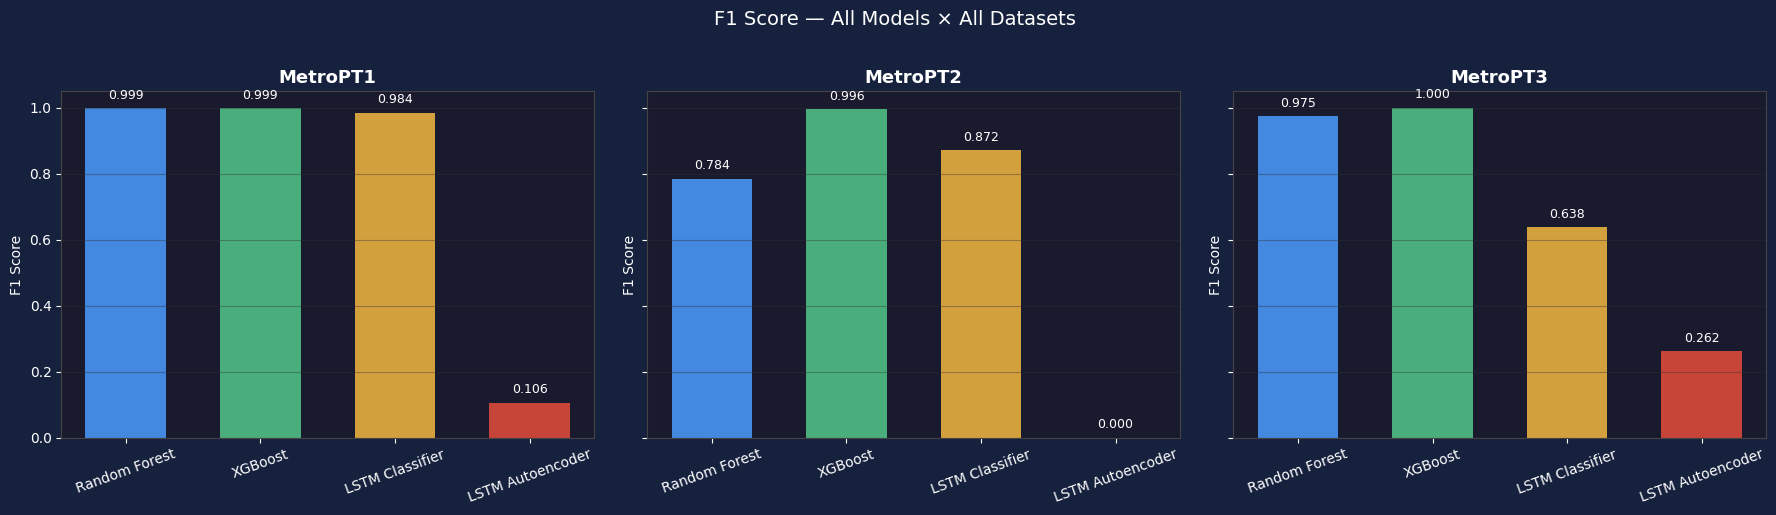

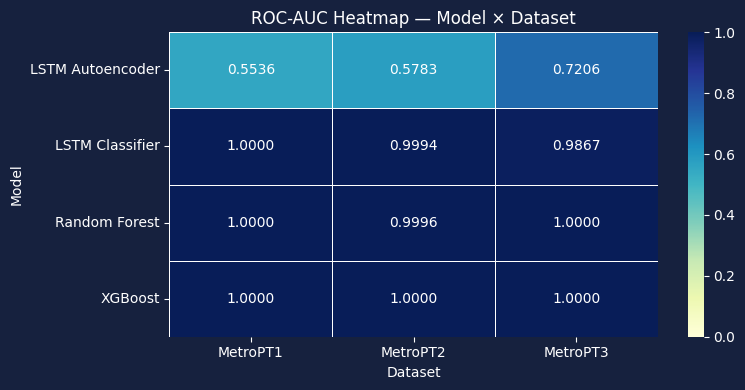

In [ ]:
# ── Bar chart: F1 per model per dataset ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = ['#4a9eff','#52c98a','#f5b942','#e74c3c']
models = list(all_results.keys())

for ax, ds in zip(axes, datasets.keys()):
    f1_vals = [all_results[m].get(ds,{}).get('metrics',{}).get('F1', 0) for m in models]
    bars = ax.bar(models, f1_vals, color=colors, alpha=0.85, width=0.6)
    ax.set_title(ds, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1 Score')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.4)
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('F1 Score — All Models × All Datasets', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('output/comparison_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Heatmap: ROC-AUC ──────────────────────────────────────
pivot = compare_df.pivot(index='Model', columns='Dataset', values='ROC-AUC')
fig2, ax2 = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, ax=ax2, vmin=0, vmax=1)
ax2.set_title('ROC-AUC Heatmap — Model × Dataset', fontsize=12)
plt.tight_layout()
plt.savefig('output/comparison_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save All Models

In [ ]:
for ds_name, d in datasets.items():
    prefix = f'model/{ds_name}'
    os.makedirs(prefix, exist_ok=True)

    # Random Forest
    if ds_name in rf_results:
        joblib.dump(rf_results[ds_name]['model'], f'{prefix}/rf.pkl')

    # XGBoost
    if ds_name in xgb_results:
        joblib.dump(xgb_results[ds_name]['model'], f'{prefix}/xgb.pkl')

    # LSTM Classifier
    if ds_name in lstm_results:
        lstm_results[ds_name]['model'].save(f'{prefix}/lstm_classifier.keras')

    # LSTM Autoencoder
    if ds_name in ae_results:
        ae_results[ds_name]['model'].save(f'{prefix}/lstm_autoencoder.keras')
        joblib.dump(ae_results[ds_name]['threshold'], f'{prefix}/ae_threshold.pkl')

    # Shared scaler + features
    joblib.dump(d['scaler'], f'{prefix}/scaler.pkl')
    joblib.dump(d['fcols'],  f'{prefix}/feature_cols.pkl')

# Save comparison table
compare_df.to_csv('output/comparison_results.csv', index=False)
joblib.dump(compare_df, 'model/comparison_df.pkl')

print('✓ All models saved in model/{DatasetName}/')
print('✓ Comparison table saved in output/comparison_results.csv')
print('\nDirectory structure:')
for root, dirs, files in os.walk('model'):
    level = root.replace('model','').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        print(f'{indent}  {f}')
print('\n✓ Now run: streamlit run app_comparison.py')

✓ All models saved in model/{DatasetName}/
✓ Comparison table saved in output/comparison_results.csv

Directory structure:
model/
  comparison_df.pkl
  MetroPT1/
    ae_threshold.pkl
    feature_cols.pkl
    lstm_autoencoder.keras
    lstm_classifier.keras
    rf.pkl
    scaler.pkl
    xgb.pkl
  MetroPT2/
    ae_threshold.pkl
    feature_cols.pkl
    lstm_autoencoder.keras
    lstm_classifier.keras
    rf.pkl
    scaler.pkl
    xgb.pkl
  MetroPT3/
    ae_threshold.pkl
    feature_cols.pkl
    lstm_autoencoder.keras
    lstm_classifier.keras
    rf.pkl
    scaler.pkl
    xgb.pkl

✓ Now run: streamlit run app_comparison.py
